In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [6]:
SEED = 42

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Configuration:")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", EPOCHS)

Configuration:
Image size: (224, 224)
Batch size: 32
Maximum epochs: 20


In [7]:
from pathlib import Path

possible_paths = [
    Path("data/cnn_train"),
    Path("../data/cnn_train")
]

TRAIN_DIR = None

for path in possible_paths:
    if path.is_dir():
        TRAIN_DIR = path.resolve()
        break

if TRAIN_DIR is None:
    raise FileNotFoundError(
        "Could not find 'cnn_train'. "
        "Please make sure the dataset is inside the 'data' folder."
    )

print("Training directory:")
print(TRAIN_DIR)
print("Exists:", TRAIN_DIR.is_dir())

Training directory:
C:\Users\dhana\Desktop\Deep-Learning-Assignment\SE4050-Deep-Learning-Assignment\data\cnn_train
Exists: True


In [8]:
print("Dataset structure")
print("=" * 60)

for item in sorted(TRAIN_DIR.iterdir()):
    if item.is_dir():
        print(f"[CLASS] {item.name}")
    else:
        print(f"[FILE]  {item.name}")

Dataset structure
[CLASS] Czech
[CLASS] India
[CLASS] Japan


In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("\nClass names:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Found 13141 files belonging to 3 classes.
Using 10513 files for training.
Found 13141 files belonging to 3 classes.
Using 2628 files for validation.

Class names: ['Czech', 'India', 'Japan']
Number of classes: 3


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

print("Dataset pipeline ready.")

Dataset pipeline ready.


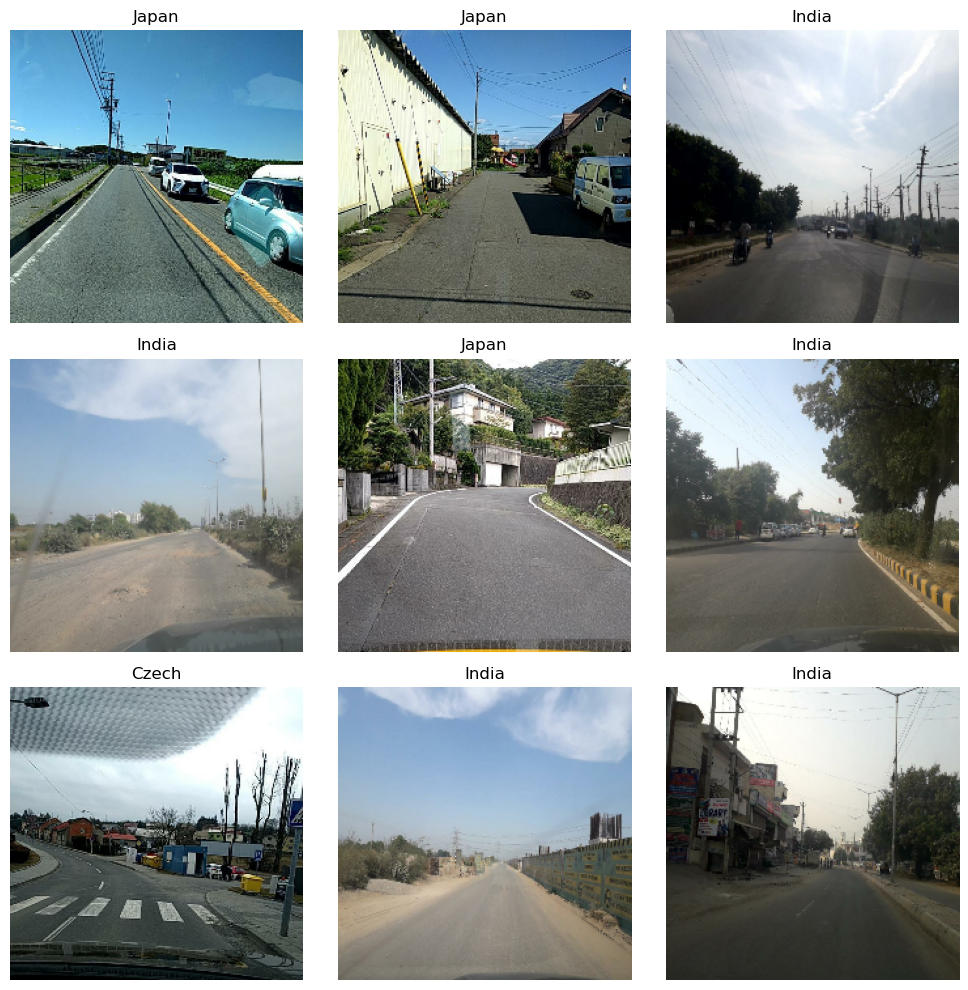

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = int(labels[i].numpy())
        plt.title(CLASS_NAMES[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully.")

Custom CNN compiled successfully.


In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/20


C:\Users\dhana\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


329/329 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.9379 - loss: 0.1863 - val_accuracy: 0.9692 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.9829 - loss: 0.0576 - val_accuracy: 0.9947 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 3/20
291/329 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.9892 - loss: 0.0329 

In [ ]:
validation_loss, validation_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print("\nCustom CNN Validation Results")
print("=" * 50)
print(f"Validation Loss     : {validation_loss:.4f}")
print(f"Validation Accuracy : {validation_accuracy:.4f}")

Found 13142 files belonging to 3 classes.
Using 10514 files for training.
Found 13142 files belonging to 3 classes.
Using 2628 files for validation.
Classes: ['Czech', 'India', 'Japan']


In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

Dataset pipeline ready.


In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Custom CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

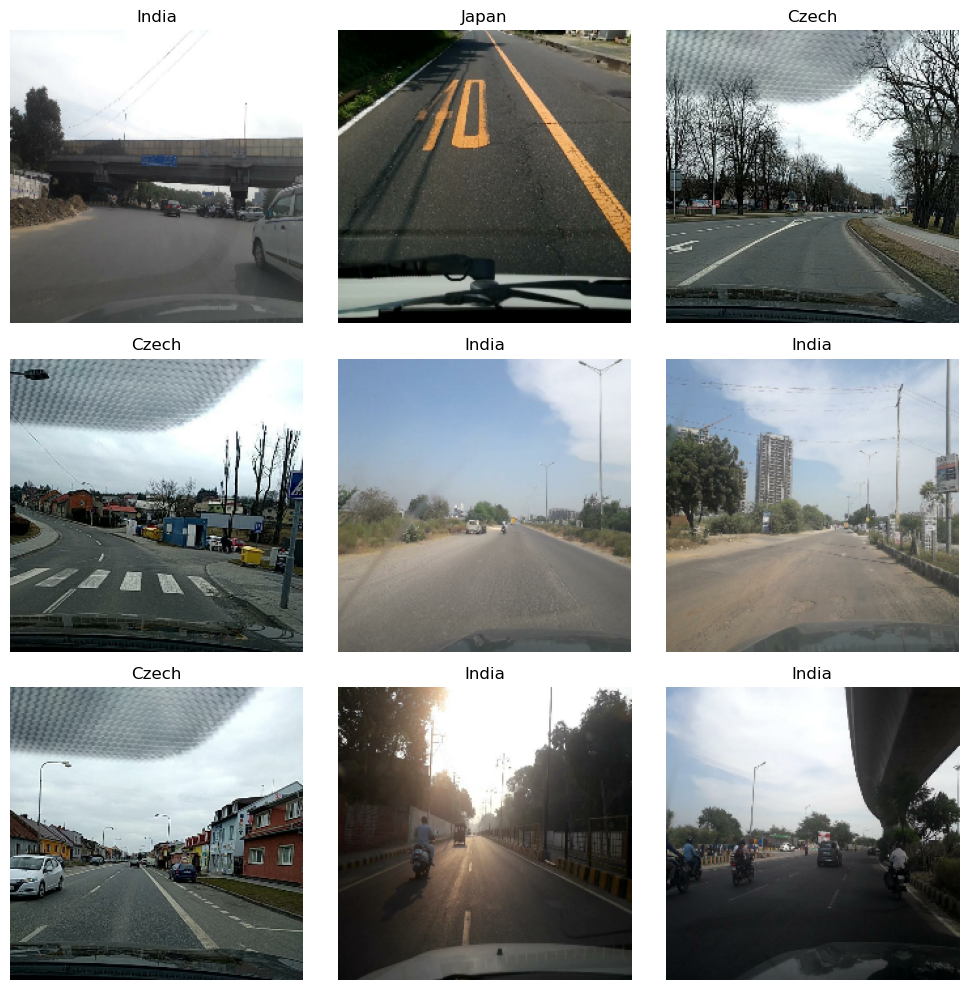

In [ ]:
print("Final Custom CNN Results")
print("=" * 50)

print(
    f"Best Validation Accuracy: "
    f"{max(history.history['val_accuracy']):.4f}"
)

print(
    f"Best Validation Loss: "
    f"{min(history.history['val_loss']):.4f}"
)

print(
    f"Final Training Accuracy: "
    f"{history.history['accuracy'][-1]:.4f}"
)

print(
    f"Final Validation Accuracy: "
    f"{history.history['val_accuracy'][-1]:.4f}"
)

print(
    f"Final Training Loss: "
    f"{history.history['loss'][-1]:.4f}"
)

print(
    f"Final Validation Loss: "
    f"{history.history['val_loss'][-1]:.4f}"
)


# Create results folder
RESULTS_DIR = Path("../results")

if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("results")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# Save the TRAINED model
model_path = RESULTS_DIR / "custom_cnn_model.keras"

model.save(model_path)

print("\nTrained Custom CNN model saved successfully:")
print(model_path)

In [55]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

Final Training Accuracy: 0.9994292855262756
Final Validation Accuracy: 0.9973363876342773
Final Training Loss: 0.0014728637179359794
Final Validation Loss: 0.010282490402460098
